In [4]:
# Choosing optimal k for K-Means: Elbow Method + Silhouette Score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#1) Create synthetic clustering data

X, _ = make_blobs( 
    n_samples=300,
    centers=4,
    cluster_std=1.0, 
    random_state=42
)

#2) Compute metrics for different k values
k_values = range(2, 15)
WCSS = [] # Within-cluster sum of squares (for Elbow) 
sil_scores = [] # Silhouette scores


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    labels = kmeans.fit_predict(X)
    
    WCSS.append(kmeans.inertia_)       #Elbow metric
    sil_scores.append(silhouette_score(X, labels))


WCSS

[9416.214004352274,
 2110.4125218953295,
 564.9141808210252,
 512.3903339109634,
 460.3079031235533,
 408.9473812641575,
 360.8214343877638,
 325.37268835521905,
 291.5608624106775,
 261.1127818951174,
 233.7657418550425,
 219.5475170972828,
 203.65412799725823]

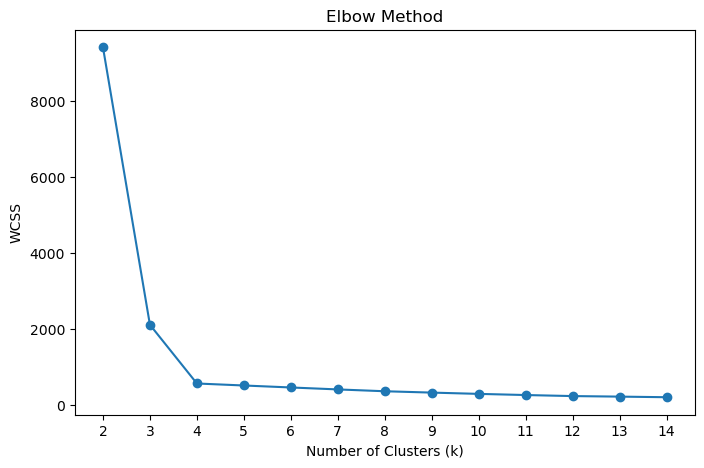

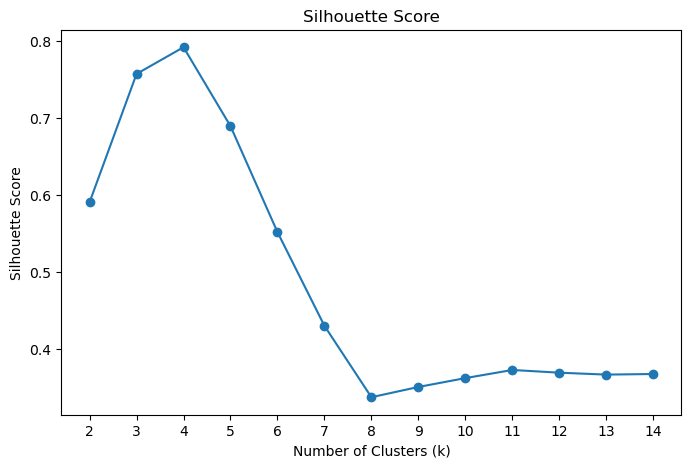

In [5]:
# 3) Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(k_values, WCSS, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.show()

# 4) Silhouette Score

plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(k_values)
plt.show()

In [6]:

#5) Print best k by silhouette

best_k = k_values[np.argmax(sil_scores)]
print(f"Best k according to Silhouette Score: {best_k}")

Best k according to Silhouette Score: 4
